# EDA (Exploratory Data Analysis)
Thực hành trên bộ dữ liệu về xe hơi

## 1. Hiểu tổng quan về bộ dữ liệu


*EDA = mô tả + trực quan để lấy insight; chưa suy nhân quả, chưa huấn luyện mô hình.*

### 1.1. Đọc dữ liệu từ file csv và hiển thị 5 dòng dữ liệu đầu tiên.

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib as plt
import os

print(os.getcwd())
print(os.listdir())


d:\02_Development_Tech_Document\DaiHocNam3\HK1\Data_Analytics_and_AI\PandasFromZeroToHero\Prac_T08
['02.ipynb', 'dataCAR.csv']


In [26]:
df=pd.read_csv('dataCAR.csv')

### 1.2. Hiển thị 5 dòng dữ liệu cuối cùng

In [27]:
df.tail(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920
11913,Lincoln,Zephyr,2006,regular unleaded,221.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Midsize,Sedan,26,17,61,28995


### 1.3. Hiển thị kiểu dữ liệu của từng cột

In [4]:
df.dtypes

Make                     str
Model                    str
Year                   int64
Engine Fuel Type         str
Engine HP            float64
Engine Cylinders     float64
Transmission Type        str
Driven_Wheels            str
Number of Doors      float64
Market Category          str
Vehicle Size             str
Vehicle Style            str
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

#### Câu hỏi ôn tập: Định nghĩa mục tiêu & nạp dữ liệu (Stage 1)

**Câu 1 (Tự luận):** Viết 3 ý: (1) bạn muốn biết gì từ dữ liệu xe, (2) kết quả phục vụ ai, (3) thế nào là phân tích “đủ tốt” ở bước EDA (ví dụ: mô tả được giá, thấy quan hệ HP–Price…).

**Câu 2 (Trắc nghiệm):** Câu nào **SAI**?
- A. Chồng thêm dòng khi hai bảng **cùng cột** (ví dụ xe năm này + năm kia)
- B. Ghép hai bảng **theo khóa** (ví dụ hồ sơ xe + bảng giá theo mẫu)
- C. Đọc CSV và đọc Excel đều là nạp **một** bảng
- D. Hai cách ghép bảng ở A và B **luôn** cho ra kết quả giống nhau, không cần phân biệt

**Câu 3 (Trắc nghiệm):** Trước khi EDA, dữ liệu dạng bảng (mỗi dòng là một quan sát, mỗi cột là một biến) được **nhập** vào pandas thành DataFrame. Câu nào **đúng**?
- A. Chỉ định dạng CSV mới đọc được thành DataFrame
- B. Có thể nhập từ nhiều định dạng và nguồn: CSV (`read_csv`), Excel (`read_excel`), hoặc bảng lấy từ kho dữ liệu (Kaggle Hub, cơ sở dữ liệu…) rồi đọc thành DataFrame. Định dạng và nguồn khác nhau; thao tác nhập thì cùng mục đích
- C. Định dạng Excel không dùng được trong EDA
- D. Phải ghép bảng (`merge`) trước thì mới đọc được tệp CSV


In [ ]:
#Cau 1
# (1) Mình muốn biết những đặc điểm và mối quan hệ quan trọng trong dữ liệu xe.
# (2) Kết quả phân tích phục vụ người mua và người bán xe trong việc đánh giá giá trị và các yếu tố ảnh hưởng đến giá xe.
# (3) Sau EDA, ta mô tả được phân bố giá xe, phát hiện dữ liệu bất thường và nhận thấy mối quan hệ giữa HP và Price.

In [ ]:
# Cau 2: D 
# Cau 3: B

## 2. Tiền xử lý dữ liệu

### 2.1. Xóa đi các cột không quan tâm
Hãy xóa các cột: 'Engine Fuel Type', 'Market Category', 'Vehicle Style', 'Popularity', 'Number of Doors', 'Vehicle Size'
Sau đó, hiển thị lại 5 dòng dữ liệu đầu tiên

In [28]:
df=df.drop(['Engine Fuel Type', 'Market Category', 'Vehicle Style', 'Popularity', 'Number of Doors', 'Vehicle Size'], axis=1)

### 2.2. Đổi tên các cột để ngắn gọn hơn

Đổi tên các cột như sau:

"Engine HP": "HP",

"Engine Cylinders": "Cylinders",

"Transmission Type": "Transmission",

"Driven_Wheels": "Drive Mode",

"highway MPG": "MPG-H",

"city mpg": "MPG-C",

"MSRP": "Price"

Sau đó, hiển thị lại 5 dòng dữ liệu đầu tiên

In [29]:
df=df.rename(columns={"Engine HP": "HP","Engine Cylinders": "Cylinders","Transmission Type": "Transmission","Driven_Wheels": "Drive Mode","highway MPG": "MPG-H","city mpg": "MPG-C","MSRP": "Price"})

In [30]:
df.head(5)

,Make,Model,Year,HP,Cylinders,Transmission,Drive Mode,MPG-H,MPG-C,Price
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


#### Câu hỏi ôn tập: Data Wrangling (Stage 1)

Pipeline: **Discovery → Structuring → Cleaning → Enriching → Validating → Publishing**

**Câu 1 (Trắc nghiệm):** Xóa cột không dùng và đổi tên (`Engine HP` → `HP`) thuộc bước nào?
- A. Discovery
- B. Structuring
- C. Enriching
- D. Publishing

**Câu 2:** Kéo mỗi việc vào đúng bước (viết Discovery / Structuring / Cleaning / Enriching / Validating / Publishing):
- xem `head`, hiểu ý nghĩa cột
- đổi tên cột, bỏ cột thừa
- xử lý trùng, ô trống, giá trị lỗi
- tạo biến mới (ví dụ tuổi xe từ `Year`)
- kiểm tra lại `shape`, missing, biểu đồ
- xuất bảng sạch để dùng tiếp

**Câu 3 (Tự luận):** Vì sao nên chuẩn hóa tên cột trước khi vẽ / thống kê? Rủi ro nếu báo cáo dùng tên cũ trong khi bảng đã đổi tên?

Cau 1: B
Cau 2: Discovery: xem `head`, hiểu ý nghĩa cột, 
Structuring: đổi tên cột, bỏ cột thừa
Cleaning: xử lý trùng, ô trống, giá trị lỗi
Enriching: tạo biến mới (ví dụ tuổi xe từ `Year`)
Validating: kiểm tra lại `shape`, missing, biểu đồ
Publishing: xuất bảng sạch để dùng tiếp
Cau 3:
Nên chuẩn hóa tên cột để tên dữ liệu ngắn gọn, dễ đọc, dễ sử dụng khi thống kê và vẽ biểu đồ, đồng thời tránh nhầm lẫn giữa các tên cột. Nếu báo cáo vẫn sử dụng tên cũ trong khi bảng dữ liệu đã đổi tên, người đọc có thể hiểu sai hoặc không đối chiếu được với dữ liệu hiện tại; khi lập trình cũng có thể xảy ra lỗi do tên cột không còn tồn tại

### 2.3. Xử lý dữ liệu trùng lặp

#### Hiển thị số dòng và số cột của bảng dữ liệu

In [8]:
df.shape

(11914, 10)

#### Hiển thị các dòng dữ liệu bị trùng

In [17]:
df[df.duplicated()]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
14,BMW,1 Series,2013,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,19,3916,31500
18,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000
20,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000
24,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000
25,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,24,17,3105,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11481,Suzuki,X-90,1998,regular unleaded,95.0,4.0,MANUAL,four wheel drive,2.0,NaN,Compact,2dr SUV,26,22,481,2000
11603,Volvo,XC60,2017,regular unleaded,302.0,4.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Luxury,Performance",Midsize,4dr SUV,29,20,870,46350
11604,Volvo,XC60,2017,regular unleaded,240.0,4.0,AUTOMATIC,front wheel drive,4.0,"Crossover,Luxury",Midsize,4dr SUV,30,23,870,40950
11708,Suzuki,XL7,2008,regular unleaded,252.0,6.0,AUTOMATIC,all wheel drive,4.0,Crossover,Midsize,4dr SUV,22,15,481,29149


#### Hiển thị số lượng giá trị phân biệt (khác nhau đôi một) của từng cột dữ liệu

In [18]:
df.nunique()

Make                   48
Model                 915
Year                   28
Engine Fuel Type       10
Engine HP             356
Engine Cylinders        9
Transmission Type       5
Driven_Wheels           4
Number of Doors         3
Market Category        71
Vehicle Size            3
Vehicle Style          16
highway MPG            59
city mpg               69
Popularity             48
MSRP                 6049
dtype: int64

#### Xóa đi những dữ liệu bị trùng lặp

**Câu hỏi gợi ý:**
1. Vì sao cần xóa dòng trùng trước khi phân tích / mô hình hóa? Nếu giữ nguyên, các chỉ số như trung bình `Price`, tần suất `Make` sẽ bị ảnh hưởng thế nào?
2. Khi xóa trùng, mặc định nên giữ dòng nào: dòng đầu, dòng cuối, hay xóa hết các bản sao? Khi nào nên đổi cách giữ?
3. Có phải mọi xe cùng `Make`, `Year`, `HP` đều là dữ liệu lỗi? Khi nào nên xét trùng theo **toàn bộ dòng**, khi nào nên xét trùng theo **một số cột**?

1. Vì dữ liệu trùng làm một quan sát được tính nhiều lần, có thể làm sai lệch trung bình, tần suất và kết quả phân tích/mô hình hóa.
2. Mặc định giữ dòng đầu tiên, có thể giữ dòng cuối hoặc xóa hết bản sao
3. Không, hai xe khác nhau có thể có cùng Make, Year, HP. Nếu muốn xác định dòng trùng hoàn toàn thì xét toàn bộ cột; nếu có khóa định danh thì có thể xét một số cột

#### Xử lý dữ liệu trùng lặp

**Câu 1 (Trắc nghiệm):** Hàm `df.drop_duplicates()` mặc định sẽ làm gì?
- A. Xóa tất cả các dòng xuất hiện nhiều hơn một lần, không giữ lại dòng nào
- B. Giữ lại dòng trùng **đầu tiên** (`keep='first'`), xóa các dòng giống hẹt phía sau
- C. Giữ lại dòng trùng **cuối cùng** (`keep='last'`)
- D. Chỉ đánh dấu trùng, không xóa dòng nào

**Câu 2 (Trắc nghiệm):** Sau khi xóa trùng, `nunique()` của từng cột thường thay đổi như thế nào?
- A. Giảm vì mỗi giá trị phân biệt bị xóa hết
- B. Tăng vì bảng dữ liệu có thêm cột mới
- C. Không đổi (hoặc gần như không đổi): số giá trị khác nhau vẫn giữ, chỉ giảm số dòng lặp
- D. Luôn bằng 0 vì dữ liệu đã bị làm sạch

**Câu 3 (Tự luận ngắn):** Giả sử hai dòng xe có cùng `Make`, `Year`, `HP`, `Cylinders` nhưng **khác `Price`**. Đó có phải là dòng trùng cần xóa bằng `drop_duplicates()` không? Nếu dùng `drop_duplicates(subset=['Make','Year','HP'])` thì rủi ro là gì đối với phân tích giá xe?

**Câu 4 (Tự luận phản biện):** Trên tập car, nhiều dòng trùng có thể là **cùng một mẫu xe được ghi hai lần** (lỗi thu thập), hoặc là **hai xe giống cấu hình thật**. Theo bạn, với mục tiêu EDA và dự đoán `Price`, nên xóa trùng toàn cục hay giữ lại? Hãy nêu **một lợi ích** và **một rủi ro** của việc xóa.

Cau 1: B
Cau 2: C
Cau 3: Không vì hai dòng khác nhau ở Price nên không phải là dòng trùng hoàn toàn. Nếu dùng drop có thể xóa nhầm hai xe hợp lệ có cùng cấu hình nhưng khác giá, làm sai lệch thông tin dự đoán
Câu 4: Với mục tiêu EDA và dự đoán Price, không nên tự động xóa tất cả dòng trùng mà cần xác định chúng là lỗi thu thập hay các xe thực tế có cùng cấu hình. Lợi ích của việc xóa là tránh một quan sát bị tính nhiều lần làm sai lệch thống kê. Rủi ro là có thể xóa nhầm các xe thực tế giống cấu hình nhưng có thông tin khác, làm ảnh hưởng dự đoán

#### Hiển thị lại số lượng giá trị phân biệt (khác nhau đôi một) của từng cột dữ liệu

In [19]:
df.nunique()

Make                   48
Model                 915
Year                   28
Engine Fuel Type       10
Engine HP             356
Engine Cylinders        9
Transmission Type       5
Driven_Wheels           4
Number of Doors         3
Market Category        71
Vehicle Size            3
Vehicle Style          16
highway MPG            59
city mpg               69
Popularity             48
MSRP                 6049
dtype: int64

### 2.4. Xử lý dữ liệu rỗng

1. Ô trống xuất hiện vì sao: ngẫu nhiên hoàn toàn, phụ thuộc cột khác đã thấy, hay phụ thuộc chính giá trị bị giấu?
2. Cột **số**, ít trống, **không phải** biến cần dự đoán, phân phối lệch: nên điền trung bình hay trung vị?
3. Cột **chữ / nhãn**: nên điền thế nào?
4. Khi nào nên **bỏ dòng** (thiếu biến mục tiêu, giá trị không hợp lệ, quá nhiều dòng trống) thay vì điền? Sau khi bỏ dòng, chỉ số dòng có thể lệch — bạn xử lý ra sao?
5. Nhiều ô “không muốn nêu”: gán nhãn riêng hay thay bằng giá trị phổ biến nhất?

1. Có thể ngẫu nhiên, phụ thuộc biến khác, hoặc phụ thuộc chính giá trị bị thiếu
2. Median
3. Mode hoặc nhãn riêng Unknown
4. Thiếu biến biến mục tiêu, dữ liệu không hợp lệ, thiếu quá nhiều
5. Giữ nhãn riêng, không tự biến thành giá trị phổ biến

#### Hiển thị số lượng giá trị rỗng của từng cột dữ liệu

In [ ]:
1. Ô trống xuất hiện vì phụ thuộc vào cột đã thấy

#### Xóa đi các giá trị rỗng, sau đó hiển thị lại số lượng giá trị phân biệt của từng cột.

In [20]:
df=df.dropna()

#### Hiển thị lại số lượng giá trị rỗng của từng cột dữ liệu

In [21]:
df.isna().sum()

Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Market Category      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64

#### Câu hỏi ôn tập: Missingness & cách xử lý ô trống (Stage 1)

**Câu 1 (Trắc nghiệm):** Ô trống ở `HP` xuất hiện hoàn toàn ngẫu nhiên (lỗi đường truyền khi cào web), không phụ thuộc thuộc tính xe. Đây là:
- A. MAR
- B. MNAR
- C. MCAR
- D. Không thuộc các cơ chế trên

**Câu 2 (Trắc nghiệm):** `Cylinders` trống chủ yếu ở xe điện vì xe điện không dùng xi-lanh — thiếu **phụ thuộc cột đã quan sát** (loại nhiên liệu / xe điện). Đây là:
- A. MCAR
- B. MAR
- C. MNAR
- D. Cả A và B

**Câu 3 (Tự luận):** MNAR là gì? Ví dụ với `Price` (người bán giấu giá vì xe quá rẻ/quá đắt). Vì sao điền **trung bình** cho `Price` trong trường hợp này làm lệch bản chất dữ liệu?

**Câu 4 (Trắc nghiệm):** Cột số, **ít** trống, **không phải** biến mục tiêu, phân phối **lệch**. Stage 1 gợi ý điền bằng gì?
- A. Trung bình (mean)
- B. Trung vị (median)
- C. Mode của cột chữ
- D. Luôn xóa hết dòng

**Câu 5 (Trắc nghiệm):** Cột chữ / phân loại (`Transmission`, `Make`) thiếu vài ô. Ưu tiên điền:
- A. Mean
- B. Median
- C. Mode 
- D. IQR

**Câu 6 (Trắc nghiệm):** Khi nào nên **xóa dòng** rồi **đặt lại chỉ số dòng**, thay vì điền?
- A. Thiếu biến mục tiêu (`Price`), giá trị không hợp lệ (ví dụ năm = −1), hoặc quá nhiều dòng trống
- B. Chỉ khi thiếu đúng 1 ô số
- C. Khi muốn giữ nguyên mọi dòng bằng mọi giá
- D. Khi biến là phân loại và muốn giữ nhãn đặc biệt

**Câu 7 (Tự luận):** Nhiều ô kiểu “không muốn nêu / Unknown”. Nên gán nhãn **Unknown** hay thay bằng mode? Vì sao mode có thể **giấu** nhóm người từ chối trả lời?

**Câu 8:** Với từng cột còn trống, hãy tự quyết định: điền (mean / median / mode / Unknown) hay xóa dòng. Viết **lý do 1 câu / cột**. Nhớ: `Price` là mục tiêu thì thiếu `Price` thường **không** điền lung tung.

Cau 1: C
Cau 2: B
Cau 3: MNAR la thieu khong ngau nhien. Dien trung binh se lam nguoi dung nham tuong ve gia
Cau 4: B
Cau 5: C
Cau 6: A
Cau 7: Nen gan nhan thay bang Unknown. Mode giau nhom nguoi tu choi tra loi bang mot nhan cu the
Cau 8: HP: Điền median vì là biến số và phân phối lệch.
Cylinders: Điền median nếu số lượng thiếu ít vì đây là biến số.
Transmission: Điền mode vì là biến phân loại.
Make: Điền mode nếu chỉ thiếu ít; nếu thể hiện “không muốn nêu” thì gán Unknown để giữ thông tin.
Price: Xóa các dòng thiếu vì Price là biến mục tiêu, không nên điền giá trị tùy ý.

### 2.5. Xử lý outlier

**Câu hỏi gợi ý:**
1. Boxplot cho `Price`, `HP`, `Cylinders` cho thấy gì (trung vị, khoảng giữa, điểm nằm ngoài)?
2. Độ trải giữa (IQR) dùng để xác định ngưỡng thế nào?
3. Ngoài **xóa** điểm lệch, còn **cắt về ngưỡng** và **kéo cực trị vào percentile**. Khác nhau ở chỗ nào (số dòng, giá trị bị đổi)? Khi nào nên xóa, khi nào nên giữ siêu xe?

#### Vẽ boxplot cho cột Price

In [24]:
print(df.columns.tolist())

['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP', 'Engine Cylinders', 'Transmission Type', 'Driven_Wheels', 'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'city mpg', 'Popularity', 'MSRP']


<Axes: xlabel='Price'>

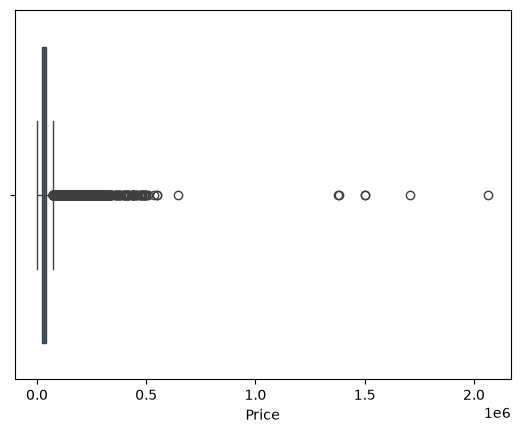

In [31]:
sns.boxplot(x='Price', data=df)

#### Vẽ boxplot cho cột HP

<Axes: xlabel='HP'>

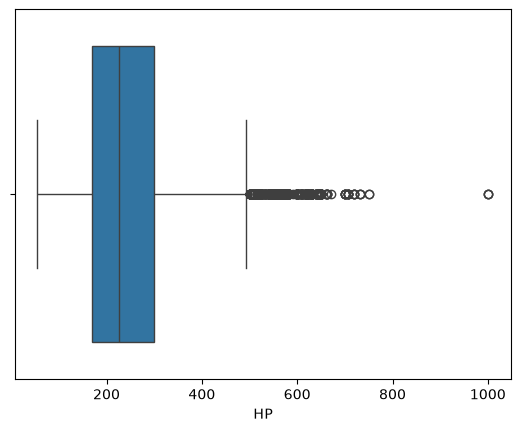

In [32]:
sns.boxplot(x='HP', data=df)

####  Vẽ boxplot cho cột Cylinders

<Axes: xlabel='Cylinders'>

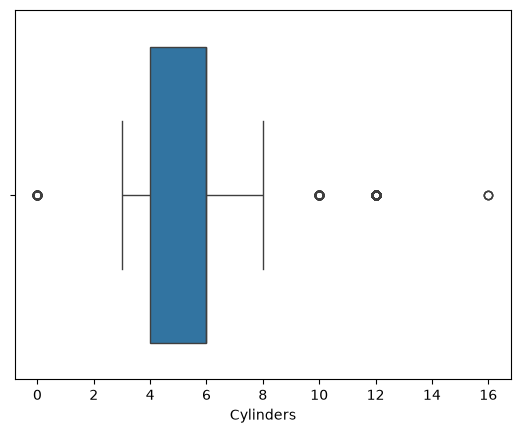

In [33]:
sns.boxplot(x='Cylinders', data=df)

#### Tìm độ trải giữa (IQR) của từng cột dữ liệu

In [35]:
numeric_df=df.select_dtypes(include='number')
iqr=numeric_df.quantile(0.75)-numeric_df.quantile(0.25)
print(iqr)

Year             9.00
HP             130.00
Cylinders        2.00
MPG-H            8.00
MPG-C            6.00
Price        21231.25
dtype: float64


#### Loại bỏ đi outlier

In [36]:
numeric_df=df.select_dtypes(include='number')
Q1=numeric_df.quantile(0.25)
Q3=numeric_df.quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3 + 1.5*IQR

df=df[~((df.select_dtypes(include='number')<lower)|
        (df.select_dtypes(include='number')>upper)).any(axis=1)]
df=df.reset_index(drop=True)

#### Câu hỏi ôn tập: Outlier & IQR (Stage 1)

**Câu 1 (Trắc nghiệm):** Một giá trị X của `Price` bị coi là outlier theo IQR (hệ số 1.5) khi:
- A. X < Q1 − 1.5 × IQR hoặc X > Q3 + 1.5 × IQR
- B. Q1 − 1.5 × IQR ≤ X ≤ Q3 + 1.5 × IQR
- C. X < Q1 − 3 × IQR hoặc X > Q3 + 3 × IQR
- D. X > Median + 1.5 × IQR

**Câu 2 (Trắc nghiệm):** Sau khi phát hiện outlier, Stage 1 nêu ba hướng. Câu nào **đúng**?
- A. Chỉ được xóa (drop); clip / winsorize là sai
- B. Có thể xóa, hoặc **clip** (cắt về ngưỡng), hoặc **winsorize** (kéo cực trị vào percentile) — tùy mục tiêu
- C. Winsorize luôn xóa dòng
- D. Clip luôn làm tăng số dòng

**Câu 3 (Tự luận):** Phân biệt **xóa** outlier, **clip**, và **winsorize** (số dòng còn lại đổi thế nào? giá trị cực trị bị thay hay bị bỏ?). Với mục tiêu hiểu **xe phổ thông**, bạn chọn hướng nào cho `Price`? Với mục tiêu mô tả **cả thị trường gồm siêu xe**, chọn hướng nào?
Drop làm giảm số dòng và loại bỏ hoàn toàn giá trị cực trị. Clip giữ nguyên số dòng nhưng cắt giá trị cực trị về ngưỡng. Winsorize cũng giữ nguyên số dòng nhưng thay các giá trị cực trị bằng giá trị tại percentile đã chọn. Với mục tiêu phân tích xe phổ thông, có thể chọn Drop nếu outlier là nhóm siêu xe không thuộc phạm vi nghiên cứu. Với mục tiêu mô tả toàn bộ thị trường gồm siêu xe, nên giữ outlier hoặc hạn chế ảnh hưởng bằng clip/winsorize thay vì xóa chúng.

**Câu 4 (Tự luận phản biện):** Xóa theo IQR trên toàn bảng có thể mất Bugatti / Ferrari vì `Price` rất cao. Nên hay không nên? Việc này giúp gì / hại gì nếu sau này chỉ muốn dự đoán giá xe phổ thông?

Không nên xóa outlier theo IQR vì các xe như Ferrari có giá rất cao là dữ liệu thực tế chứ không sai. Nếu là dữ liệu phổ thông thì có thể xóa. Nhược điểm là làm mất thông tin, dữ liệu không đại diện cho toàn bộ thị trường.

**Câu 5 (Ôn — làm được):** Tự tính IQR cho các cột số, chỉ ra ngưỡng dưới/trên, và giải thích trước khi xóa: cột nào outlier là lỗi, cột nào outlier là xe thật.

In [37]:
numeric_df=df.select_dtypes(include='number')
Q1=numeric_df.quantile(0.25)
Q3=numeric_df.quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

Cau 1: A
Cau 2: B
Cau 3: Khi xoa, so dong con lai giam, loai bo hoan toan gia tri cuc tri.
    Clip lam so dong con lai khong thay doi, gia tri cuc tri duoc thay bang nguong tren hay nguong duoi
    

## 3. Trực quan hóa dữ liệu

**Gợi ý ôn:** biến số → phân phối; biến nhóm → đếm tần suất; hai biến số → scatter; nhiều cột số → heatmap; so sánh phân phối theo nhóm → box/violin. Khi các hãng có **số mẫu khác nhau**, cân nhắc **tỷ lệ** chứ đừng chỉ đếm. Chỉnh tiêu đề, trục, nhiều plot một hình, lưu ảnh — cần kiểm soát figure/axes, không chỉ gọi lệnh vẽ nhanh.

### 3.1. Vẽ histogram cho cột Make

<Axes: xlabel='Count', ylabel='Make'>

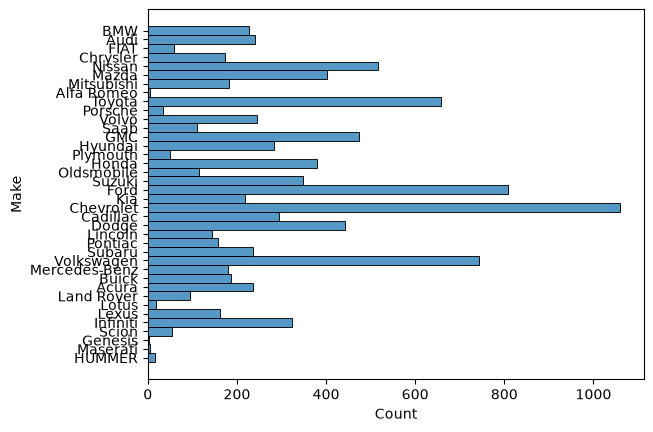

In [40]:
sns.histplot(y='Make', data=df)

### 3.2. Vẽ biểu đồ nhiệt

<Axes: >

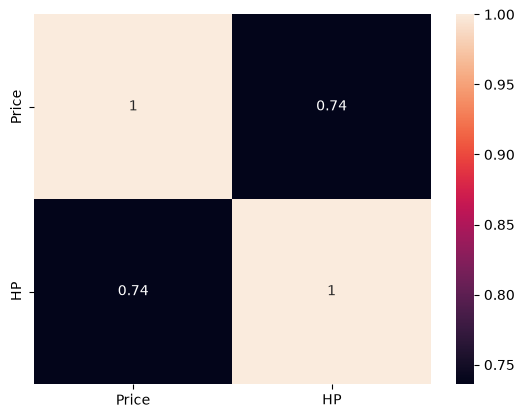

In [43]:
sns.heatmap(df[['Price','HP']].corr(), annot=True)

### 3.3. Vẽ biểu đồ scatter cho Price và HP

<Axes: xlabel='Price', ylabel='HP'>

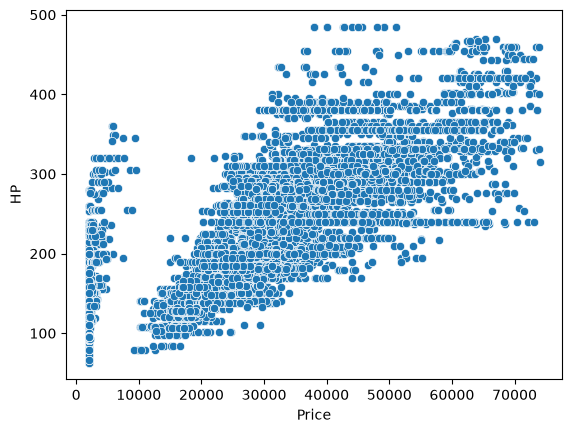

In [44]:
sns.scatterplot(x='Price', y='HP', data=df)

#### Câu hỏi ôn tập: EDA 6 bước & trực quan (Stage 1)

**Nhắc:** EDA = mô tả + trực quan để lấy *insight*. Chưa kết luận nhân quả, chưa huấn luyện mô hình.

**Câu 1 (Trắc nghiệm):** Mục tiêu đúng của EDA là gì?
- A. Chứng minh HP **gây ra** giá xe
- B. Mô tả phân phối và quan hệ để hiểu dữ liệu; chưa nhân quả, chưa ML
- C. Chỉ cần đủ để chạy hồi quy là xong
- D. Thay thế toàn bộ kiểm định giả thuyết

**Câu 2 (Trắc nghiệm):** `Make` là biến **phân loại** (hãng xe). Biểu đồ nào **phù hợp hơn** để xem tần suất từng hãng?
- A. Histogram (dành phân phối biến số)
- B. Biểu đồ đếm theo nhóm (bar / countplot)
- C. Heatmap tương quan
- D. Scatter `Price` vs `HP`

**Câu 3 (Tự luận):** Chevrolet có **nhiều dòng** hơn Alfa Romeo. Nếu chỉ soánh **số lượng** xe đắt theo hãng, kết luận có thể lệch ở đâu? Vì sao khi cỡ mẫu khác nhau nên nhìn **tỷ lệ (rate)** thay vì chỉ **count**?
Khi cỡ mẫu giữa các hãng khác nhau, chỉ so sánh count có thể gây sai lệch vì hãng có nhiều quan sát hơn thường sẽ có số lượng xe đắt cao hơn. Nên sử dụng tỷ lệ.

**Câu 4 (Tự luận — làm được):** Với tập xe, bạn chọn loại biểu đồ nào cho từng nhu cầu? Viết 1 câu / nhu cầu, **không cần dán code**:
- phân phối `Price` hoặc `HP`  histogram
- tần suất `Transmission` hoặc `Make` countplot
- quan hệ hai biến số `HP` và `Price` scatterplot
- tương quan nhiều cột số (heatmap) 
- so sánh phân phối giá theo nhóm (box / violin) boxplot

**Câu 5 (Trắc nghiệm — đúng/sai, chọn câu sai):** Về Matplotlib / Seaborn, câu **SAI** là:
- A. Seaborn vẽ nhanh từ DataFrame; vẫn dùng Matplotlib để chỉnh title, trục, layout, lưu ảnh Đ
- B. Có hai kiểu viết: gọi trực tiếp `plt...` hoặc dùng `fig, ax = ...` (object-oriented) Đ
- C. Seaborn **thay thế hoàn toàn** Matplotlib, không cần học `ax` / `plt` nữa S
- D. Tô màu theo nhóm dùng `hue`; nhiều plot một figure dùng subplots Đ

**Câu 6 (Tự luận ngắn — feature engineering):** Đề xuất **một** biến mới từ `Year`, **một** cách chia nhóm (bin) cho `HP` hoặc `Price`, và nêu vì sao biến phân loại như `Transmission` thường cần mã hóa (dummy) **nếu** sau này đưa vào mô hình. EDA bước này chưa bắt buộc scale — vì sao vẫn nên *biết* scaling là gì?
Có thể tạo biến Age=now - year để biểu diễn tuổi xe; chia HP thành các nhóm thấp, trung bình, cao để dễ so sánh. Biến phân loại như Transmission cần mã hóa thành biến số nếu đưa vào mô hình vì nhiều mô hình ML yêu cầu dữ liệu dạng số. EDA chưa bắt buộc scaling, nhưng cần biết scaling vì một số thuật toán như KNN, K-means, SVM và PCA nhạy với sự khác nhau về thang đo giữa các biến.

**Câu 7 (Tổng kết — làm được):** Viết **3 insight** từ biểu đồ (ví dụ: giá lệch, HP đi kèm giá, hãng nào chiếm nhiều mẫu…) và **1 caveat** (giới hạn: outlier siêu xe, dữ liệu cũ, hãng lệch số lượng, EDA không suy nhân quả).
Xe Chevrolet có số lượt bán cao nhất dựa trên biểu đồ countplot
HP và Price có tương quan mạnh dựa trên biểu đồ scatterplot


Cau 1:B
Cau 2:B

#BÀI TOÁN KIỂM ĐỊNH
1. CHO 1 BÀI TOÁN KIỂM ĐỊNH T-TEST
2. CHO 1 BÀI TOÁN KIỂM ĐỊNH Z-TEST
3. CHO 1 BÀI TOÁN KIỂM ĐỊNH CHI-SQUARE
4. CHO 1 BÀI TOÁN KIỂM ĐỊNH ANOVA

In [63]:
# 1. Bài toán kiểm định T-Test
# Câu hỏi nghiên cứu: Liệu giá cả trung bình của các xe có động cơ 6 xi lanh có khác biệt đáng kể so với giá cả trung bình của các xe có động cơ 4 xi lanh không?

# Giả thuyết null (H0): Giá cả trung bình của xe 6 xi lanh bằng giá cả trung bình của xe 4 xi lanh.
# Giả thuyết đối (H1): Giá cả trung bình của xe 6 xi lanh khác với giá cả trung bình của xe 4 xi lanh.

from scipy import stats

# Lọc dữ liệu cho xe có động cơ 4 và 6 xi lanh
cars_4_cylinders = df[df['Cylinders'] == 4]['Price']
cars_6_cylinders = df[df['Cylinders'] == 6]['Price']

# Thực hiện kiểm định T-Test
t_statistic, p_value = stats.ttest_ind(cars_4_cylinders, cars_6_cylinders)

# In kết quả
print(f"T-Statistic: {t_statistic}")
print(f"P-Value: {p_value}")

# Quyết định về giả thuyết
alpha = 0.05  # Mức ý nghĩa
if p_value < alpha:
    print("Bác bỏ H0: Giá cả trung bình của xe 6 xi lanh khác với xe 4 xi lanh.")
else:
    print("Không bác bỏ H0: Giá cả trung bình của xe 6 xi lanh bằng với xe 4 xi lanh.")

T-Statistic: -29.49501080687058
P-Value: 4.5622876250881345e-182
Bác bỏ H0: Giá cả trung bình của xe 6 xi lanh khác với xe 4 xi lanh.


In [64]:
# 2. Bài toán kiểm định Z-Test
# Câu hỏi nghiên cứu: Liệu giá trung bình của xe trong mẫu có khác biệt đáng kể so với mức giá trung bình đã biết của toàn bộ xe trên thị trường (giả sử là 30,000 USD)?

# Giả thuyết null (H0): Giá trung bình của xe trong mẫu bằng 30,000 USD.
# Giả thuyết đối (H1): Giá trung bình của xe trong mẫu khác với 30,000 USD.

# Lấy giá cả của xe trong mẫu
sample_prices = df['Price']

# Tính toán các thông số cần thiết
sample_mean = np.mean(sample_prices)
sample_std = np.std(sample_prices, ddof=1)  # ddof=1 để tính độ lệch chuẩn mẫu
n = len(sample_prices)
known_mean = 30000  # Giá trung bình đã biết

# Tính giá trị Z
z_value = (sample_mean - known_mean) / (sample_std / np.sqrt(n))

# Tính giá trị p từ giá trị Z
p_value = 2 * (1 - stats.norm.cdf(abs(z_value)))  # Nhân đôi để kiểm định hai phía

# In kết quả
print(f"Z-Value: {z_value}")
print(f"P-Value: {p_value}")

# Quyết định về giả thuyết
alpha = 0.05  # Mức ý nghĩa
if p_value < alpha:
    print("Bác bỏ H0: Giá trung bình của xe trong mẫu khác với 30,000 USD.")
else:
    print("Không bác bỏ H0: Giá trung bình của xe trong mẫu bằng 30,000 USD.")

Z-Value: 20.86795578382845
P-Value: 0.0
Bác bỏ H0: Giá trung bình của xe trong mẫu khác với 30,000 USD.


In [65]:
# 3. Bài toán kiểm định Chi-Square
# Câu hỏi nghiên cứu: Có sự liên quan nào giữa loại xe (Make) và kiểu truyền động (Transmission Type) không?

# Giả thuyết null (H0): Không có sự liên quan giữa loại xe và kiểu truyền động.
# Giả thuyết đối (H1): Có sự liên quan giữa loại xe và kiểu truyền động.

# Tạo bảng tần số cho loại xe và kiểu truyền động
contingency_table = pd.crosstab(df['Make'], df['Transmission'])

# In bảng tần số
print("Bảng tần số:")
print(contingency_table)

# Thực hiện kiểm định Chi-Square
chi2_statistic, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# In kết quả
print(f"\nChi-Square Statistic: {chi2_statistic}")
print(f"P-Value: {p_value}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies:\n{expected}")

# Quyết định về giả thuyết
alpha = 0.05  # Mức ý nghĩa
if p_value < alpha:
    print("Bác bỏ H0: Có sự liên quan giữa loại xe và kiểu truyền động.")
else:
    print("Không bác bỏ H0: Không có sự liên quan giữa loại xe và kiểu truyền động.")

Bảng tần số:
Transmission   AUTOMATED_MANUAL  AUTOMATIC  DIRECT_DRIVE  MANUAL  UNKNOWN
Make                                                                     
Acura                        21        169             0      56        0
Alfa Romeo                    5          0             0       0        0
Aston Martin                 22         38             0      31        0
Audi                        121        140             0      59        0
BMW                          18        246             4      56        0
Bentley                       0         74             0       0        0
Bugatti                       3          0             0       0        0
Buick                         0        184             0       0        0
Cadillac                      0        385             0      11        0
Chevrolet                     0        711             8     324        0
Chrysler                      0        167             0      16        2
Dodge                    

In [45]:
# 4. Bài toán kiểm định ANOVA
# Câu hỏi nghiên cứu: Liệu giá cả trung bình của các xe có sự khác biệt giữa các loại động cơ (ví dụ: động cơ 4, 6 và 8 xi lanh) không?

# Giả thuyết null (H0): Giá cả trung bình của xe giữa các loại động cơ là như nhau.
# Giả thuyết đối (H1): Ít nhất một trong các giá trị giá cả trung bình giữa các loại động cơ là khác nhau.

# Nhóm giá cả xe theo từng loại động cơ
grouped_data = [group['Price'].values for name, group in df.groupby('Cylinders')]

# Thực hiện kiểm định ANOVA
f_statistic, p_value = stats.f_oneway(*grouped_data)

# In kết quả
print(f"F-Statistic: {f_statistic}")
print(f"P-Value: {p_value}")

# Quyết định về giả thuyết
alpha = 0.05  # Mức ý nghĩa
if p_value < alpha:
    print("Bác bỏ H0: Có sự khác biệt giữa giá cả trung bình của các loại động cơ.")
else:
    print("Không bác bỏ H0: Giá cả trung bình của xe giữa các loại động cơ là như nhau.")

NameError: name 'stats' is not defined